# Modelo supervisionado: Um modelo que aprende com exemplos rotulados (você diz a resposta certa):
Você mostra uma foto e fala:
- "Isso é um cachorro" 🐕
# Modelo Não Supervisionado:
Você mostra fotos mas NÃO fala o nome:
- [mostra foto] (sem dizer o animal)
A criança agrupa por conta própria:
- "Esse grupo de 4 fotos tem orelhas pontudas"
- "Esse outro grupo tem barbatanas"
(Mas não sabe o que é "cachorro" ou "peixe")

---Na aula de hoje vamos aprender a como criar um classificador automático e inteligente utilizando ferramentas de machine learning.


Case: Classificação de insetos gafanhotos e esperanças

Um certo cientista coletou dados de amostra sobre uma população de insetos da espécie gafanhoto e esperança para realizar um estudo e identificar uma forma de encontrar diferenças entre os tipos de insetos analisando algumas das características presentes no corpo dos insetos.

Com base em suas pesquisas e análises, o cientista identificou que as características do tamanho do abdomên e comprimento das antenas desses insetos podem ser um fator muito relevante para a identificação da espécie.

O cientista precisa encontrar uma maneira de identificar de forma automática e precisa os padrões dessas características que podem classificar quando um inseto é do tipo gafanhoto ou do tipo esperança.

Vamos aplicar machine learning para resolver esse problema?

In [1]:
import pandas as pd
dados = pd.read_excel("gaf_esp.xlsx")
dados.head()

#variavel target é a resposta do comportamento ex: no comp. do abdomen e das antenas eu tenho uma resposta do que significa os dados. 
# No modelo supervisionado ela é obrigatório.

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [4]:
dados.shape

(100, 3)

In [8]:
dados.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Comprimento do Abdômen,100.0,4.94,3.34,0.50,1.69,4.5,8.2,10.0
Comprimento das Antenas,100.0,5.38,2.30,0.89,3.78,5.5,7.0,9.7


In [12]:
#entendendo a classificação dos garfanhotos

dados.groupby("Espécie").describe().round(2)

Comprimento do Abdômen                                           \
                           count  mean   std  min   25%   50%   75%   max   
Espécie                                                                     
Esperança                   50.0  8.12  1.13  5.4  7.22  8.20  9.00  10.0   
Gafanhoto                   50.0  1.75  0.79  0.5  1.20  1.68  2.42   3.6   

          Comprimento das Antenas                                          
                            count  mean   std   min   25%   50%  75%  max  
Espécie                                                                    
Esperança                    50.0  7.22  1.33  4.50  6.20  7.00  8.2  9.7  
Gafanhoto                    50.0  3.55  1.42  0.89  2.55  3.77  4.3  7.0

<Axes: xlabel='Comprimento do Abdômen', ylabel='Comprimento das Antenas'>

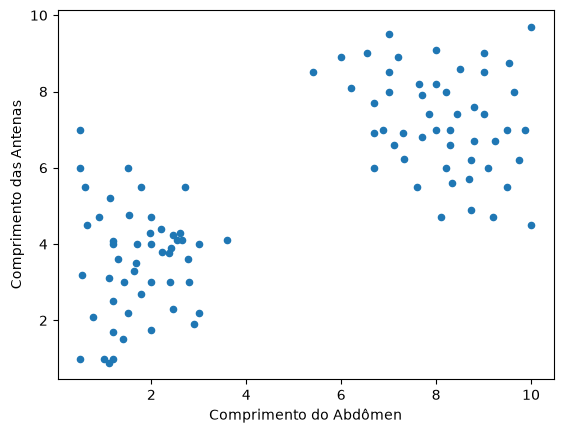

In [18]:
#Gráfico de dispersão

dados.plot.scatter(x ="Comprimento do Abdômen", y = "Comprimento das Antenas")


In [21]:
from sklearn import * #importa tudo da biblioteca sklearn
from sklearn.model_selection import train_test_split

In [ ]:
x = dados[["Comprimento do Abdômen", "Comprimento das Antenas"]] # mais de um colchete é pq são mais de uma variável
y = dados["Espécie"] # minha váriavel target

In [28]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, stratify=y, random_state=42 )
 #stratify equilibrio para pegar a mesma qnt de garfanhoto e de esperança

In [ ]:
#Verificando a quantidade de dado distribuido para cada variavel
list(y_train).count("Esperança")



40

In [31]:
#Verificando a quantidade de dado distribuido para cada variavel
list(y_train).count("Gafanhoto")

40

In [ ]:
#verificando quanto eu tenho em teste -20%
len(x_test)

20

In [ ]:
#verificando quanto eu tenho em treino -80%
len(x_train)

80

ALGOTIMO ---- KNEIGBOR - KNN - VIZINHOS

In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
modelo_classificador = KNeighborsClassifier(n_neighbors=3) 
#n_neighbors é a qnt de vizinhos e é um hiperparametro
#Quanto maior o número = mais generalista
#Quanto menor o número = mais específico

In [36]:
modelo_classificador.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['Esperança','Gafanhoto']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#PREVISÕES

In [ ]:
modelo_classificador.predict([[8,6]])  
# Sugerindo um valor de referencia para a o valor de comprimento de abdomen e de antena
# a resposta foi correta com a esperança

c:\Users\barre\OneDrive\Documentos\Laura - FIAP\Fase -2\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Esperança'], dtype=object)

Métricas de Classficação para garantir que o modelo esta indo bem

In [38]:
y_predito = modelo_classificador.predict(x_test)

In [39]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_true = y_test, y_pred = y_predito)
#acuracia deu 100%, será que faz sentido? --- Desconfiar de modelos que tem muita proximidade de 100 ( 99%, 100%)

1.0